# Accelerated Proximal Point Method (APPM) / Optimal Halpern Method (OHM)

This code outlines the procedure for Lyapunov function discovery for the
Accelerated Proximal Point Method, an exact optimal method for reducing
the fixed-point residual $\|x - J_{\alpha A}x\|$ with respect to the 
initial distance to the solution for a maximally monotone operator A, 
introduced in "Accelerated proximal point method for maximally monotone 
operators" by Donghwan Kim (2021). This method is equivalent to 
the Optimal Halpern Method, which was studied in "On the Convergence 
Rate of the Halpern Iteration" by Felix Lieder (2021).

## Import the required libraries

In [1]:
import pepflow as pf
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display, Math

import pepflow.lyapunov_utils as lu

## Define the operators

In [2]:
A = pf.MonotoneOperator(is_basis=True, tags=["A"])

## Write a function that generates a PEPContext object associated with APPM/OHM

In [3]:
def make_ctx_appm(
    ctx_name: str, N: int | sp.Integer, stepsize: pf.Parameter
) -> pf.PEPContext:
    ctx_appm = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    y = x.add_tag("y_0")
    A.set_zero_point("x_star")
    for i in range(N):
        x = A.resolvent(y, stepsize, tag=f"x_{i + 1}")
        y = (
            sp.S(i + 1) / sp.S(i + 2) * (sp.S(2) * x - y)
            + sp.S(1) / sp.S(i + 2) * ctx_appm["x_0"]
        ).add_tag(f"y_{i + 1}")

    return ctx_appm

## Numerical evidence showing that APPM/OHM converges at the rate $\|\tilde{A}x_N\|^2 \le \frac{\|x_0 - x_\star\|^2}{N^2}$

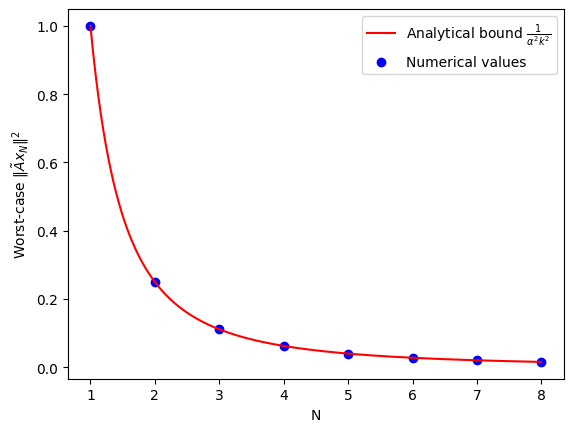

In [4]:
N = 8
alpha = pf.Parameter("alpha")
R = pf.Parameter("R")
alpha_value = 1
R_value = 1

ctx_plt = make_ctx_appm(ctx_name="ctx_plt", N=N, stepsize=alpha)
pb_plt = pf.PEPBuilder(ctx_plt)
pb_plt.add_initial_constraint(
    ((ctx_plt["x_0"] - ctx_plt["x_star"]) ** 2).le(R, name="initial_condition")
)

opt_values = []
for k in range(1, N + 1):
    x_k = ctx_plt[f"x_{k}"]
    pb_plt.set_performance_metric(A(x_k) ** 2)
    result = pb_plt.solve(resolve_parameters={"alpha": alpha_value, "R": R_value})
    opt_values.append(result.opt_value)

iters = np.arange(1, N + 1)
cont_iters = np.arange(1, N, 0.01)
plt.plot(
    cont_iters,
    1 / (alpha_value**2 * cont_iters**2),
    "r-",
    label="Analytical bound $\\frac{1}{\\alpha^2 k^2}$",
)
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.xlabel("N")
plt.ylabel(r"Worst-case $\|\tilde{A} x_N\|^2$")
plt.legend()

## Verification of convergence of APPM

In [5]:
N = sp.S(4)
alpha_value = sp.S(1)
R_value = sp.S(1)

ctx_prf = make_ctx_appm(ctx_name="ctx_prf", N=N, stepsize=alpha)
pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2).le(R, name="initial_condition")
)
pb_prf.set_performance_metric(A(ctx_prf[f"x_{N}"]) ** 2)

result = pb_prf.solve(resolve_parameters={"alpha": alpha_value, "R": R_value})
print(result.opt_value)

# Dual variables associated with the interpolations conditions of f with no relaxation
lamb_dense = result.get_scalar_constraint_dual_value_in_numpy(A)

0.06250301959936219


### It turns out that no relaxation of dual variables is needed (the solver output is already sparse), so we store the results


In [6]:
# Dual variable associated with the initial condition
tau_sol = result.dual_var_manager.dual_value("initial_condition")

# Dual variable associated with the interpolations conditions of A
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(A)

# Dual variable associated with the Gram matrix G
S_sol = result.get_gram_dual_matrix()

In [7]:
lamb_sol.pprint()

<IPython.core.display.Math object>

In [8]:
S_sol.pprint()

<IPython.core.display.Math object>

### The Gram dual matrix $S$ has rank 1

In [9]:
np.linalg.matrix_rank(S_sol.matrix)

np.int64(1)

---

## Step 1. Propose a candidate Lyapunov function

### Choose $\mathcal{I}_k = \{(j+1,j): j=1,\dots,k\}, \mathcal{I}_0 = \emptyset, \mathcal{J}_k = \emptyset$

In [10]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for j in np.arange(1, N):
    partial_sum += lamb_sol(f"x_{j}", f"x_{j + 1}") * A.interp_ineq(
        f"x_{j}", f"x_{j + 1}"
    )
    lyap.append(partial_sum)

## Step 2. Check for admissibility

### Sufficiency is immediate.
### To check rank consistency and conciseness, verify that the ranks of $\mathbf{V}_k$ are constantly 2

In [11]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"alpha": sp.S(1)})

for k in range(len(lyap)):
    lyap_numeric_k = pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float)
    print(f"Rank of lyap[{k}]: {np.linalg.matrix_rank(lyap_numeric_k, tol=1e-6)}")

Rank of lyap[0]: 0
Rank of lyap[1]: 2
Rank of lyap[2]: 2
Rank of lyap[3]: 2


## Step 3. Build a set of special candidate vectors

In [12]:
lyap_basis_candidate = ctx_prf.basis_vectors()  # add x_0, x_star and Ax_1, ... , Ax_N
x = [ctx_prf[f"x_{i}"] for i in range(1, N + 1)]
# Add x_1, ... , x_N
lyap_basis_candidate += x

# Add all pairwise differences between the previous special vectors
for i, j in combinations(range(len(lyap_basis_candidate)), 2):
    diff = lyap_basis_candidate[i] - lyap_basis_candidate[j]
    diff.add_tag(f"{lyap_basis_candidate[i].tag}-{lyap_basis_candidate[j].tag}")
    lyap_basis_candidate.append(diff)

In [13]:
print(lyap_basis_candidate)

[y_0, x_star, A(x_1), A(x_2), A(x_3), A(x_4), x_1, x_2, x_3, x_4, y_0-x_star, y_0-A(x_1), y_0-A(x_2), y_0-A(x_3), y_0-A(x_4), y_0-x_1, y_0-x_2, y_0-x_3, y_0-x_4, x_star-A(x_1), x_star-A(x_2), x_star-A(x_3), x_star-A(x_4), x_star-x_1, x_star-x_2, x_star-x_3, x_star-x_4, A(x_1)-A(x_2), A(x_1)-A(x_3), A(x_1)-A(x_4), A(x_1)-x_1, A(x_1)-x_2, A(x_1)-x_3, A(x_1)-x_4, A(x_2)-A(x_3), A(x_2)-A(x_4), A(x_2)-x_1, A(x_2)-x_2, A(x_2)-x_3, A(x_2)-x_4, A(x_3)-A(x_4), A(x_3)-x_1, A(x_3)-x_2, A(x_3)-x_3, A(x_3)-x_4, A(x_4)-x_1, A(x_4)-x_2, A(x_4)-x_3, A(x_4)-x_4, x_1-x_2, x_1-x_3, x_1-x_4, x_2-x_3, x_2-x_4, x_3-x_4]


## Step 4. Find a basis of $\mathbf{V}_k$ within lyap_basis_candidate

### We find that $Ax_{k+1}$ and $x_0 - x_{k+1}$ is the correct choice

In [14]:
for k in range(len(lyap)):
    print(
        f"V_{k}:",
        lu.vectors_in_column_space(
            lyap[k],
            lyap_basis_candidate,
            ctx_prf,
            resolve_parameters=pm.resolve_parameters,
            rtol=1e-4,
            atol=1e-4,
        ),
    )

V_0: []
V_1: [A(x_1), A(x_2), y_0-x_1, y_0-x_2, A(x_1)-A(x_2), x_1-x_2]
V_2: [A(x_3), y_0-x_3]
V_3: [A(x_4), y_0-x_4]


### We can numerically inspect the coefficient matrix. In particular, coefficient of the $\|y_0 - x_{k+1}\|^2$ term seems to be $0$
### Define $V_k = a_k \|\tilde{A}x_{k+1}\|^2 + b_k \langle \tilde{A}x_{k+1} , y_0 - x_{k+1} \rangle$

In [15]:
for k in np.arange(1, len(lyap)):
    aligned_special_vectors_k = [ctx_prf[f"A(x_{k + 1})"], ctx_prf[f"y_0-x_{k + 1}"]]
    C_k = lu.find_symmetric_coefficient_matrix(
        lyap[k],
        aligned_special_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels_k = [str(v) for v in aligned_special_vectors_k]
    print(f"V_{k}:")
    pf.pprint_labeled_matrix(C_k, labels_k, labels_k)

V_1:


<IPython.core.display.Math object>

V_2:


<IPython.core.display.Math object>

V_3:


<IPython.core.display.Math object>

---

## Step 5. Analytic proof

### We first need closed-form expressions of $\lambda$ and $S$.
### This can be done from numerical inspection with different $N$. Here we show how to check your guess by code

In [16]:
def tag_to_index(tag, N=N):
    """Return the iterate index encoded in a point tag.

    The zero point y_star is indexed as N + 1.
    """
    idx = tag.split("_", 1)[1]
    if idx.isdigit():
        return int(idx)
    if idx == "star":
        return N + 1
    raise ValueError(f"Unknown point tag: {tag}")

### Candidate formula for $\lambda$

In [17]:
def lamb(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i)
    j = tag_to_index(tag_j)
    if j - 1 == i:
        if j == N + 1:
            return sp.S(2) / N  ## Between N and optimal
        else:
            return sp.S(2) * (sp.S(j) - sp.S(1)) * sp.S(j) / N**2  ## Consecutive
    return 0


lamb_cand = pf.pprint_labeled_matrix(
    lamb, lamb_sol.row_names, lamb_sol.col_names, return_matrix=True
)

<IPython.core.display.Math object>

### Verify that the prposed formula matches with numerical values

In [18]:
print(
    "Did we guess the right closed form of lambda?",
    np.allclose(lamb_cand, lamb_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of lambda? True


### Candidate formula for $S$

In [19]:
ctx_prf.basis_vectors()

[y_0, x_star, A(x_1), A(x_2), A(x_3), A(x_4)]

In [20]:
x_0 = ctx_prf["x_0"]
x_N = ctx_prf[f"x_{N}"]
x_star = ctx_prf["x_star"]

S_guess = (A(x_N) - 1 / (alpha * N) * (x_0 - x_star)) ** 2

S_guess_eval = pm.eval_scalar(S_guess).matrix
pf.pprint_labeled_matrix(S_guess_eval, S_sol.row_names, S_sol.col_names)

<IPython.core.display.Math object>

### Again, verify that the prposed formula matches with numerical values

In [21]:
print(
    "Did we guess the right closed form of S?",
    np.allclose(S_guess_eval, S_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of S? True


### Finally, we symbolically determine the Lyapunov function coefficients

In [22]:
# New PEP context for symbolic solve and verification
ctx_appm_lyap = pf.PEPContext("appm_lyap_finder").set_as_current()

### APPM is equivalent to OHM $y_{k+1} = \frac{1}{k+2} y_0 + \frac{k+1}{k+2} Ty_k$ with $T=2J_A - I$
### Express $V_k - V_{k+1} - \frac{2(k+1)(k+2)}{N^2} \langle \tilde{A}x_{k+1} - \tilde{A}x_{k+2} , x_{k+1} - x_{k+2} \rangle = 0$ as a system of equations and solve for $a_k, b_k, a_{k+1}, b_{k+1}$

In [23]:
y_0 = pf.Vector(is_basis=True, tags=["y_0"])
y_k = pf.Vector(is_basis=True, tags=["y_k"])
Ax_k1 = pf.Vector(is_basis=True, tags=["Ax_{k+1}"])
Ax_k2 = pf.Vector(is_basis=True, tags=["Ax_{k+2}"])
k = pf.Parameter("k")
alpha = 1

y_k1 = 1 / (k + 2) * y_0 + (k + 1) / (k + 2) * (y_k - 2 * Ax_k1)

a_k = pf.Parameter("a_k")
a_k1 = pf.Parameter("a_{k+1}")
b_k = pf.Parameter("b_k")
b_k1 = pf.Parameter("b_{k+1}")
N = pf.Parameter("N")

x_k1 = y_k - Ax_k1
x_k2 = y_k1 - Ax_k2

V_k = a_k * Ax_k1 * Ax_k1 + b_k * (y_0 - x_k1) * Ax_k1
V_k1 = a_k1 * Ax_k2 * Ax_k2 + b_k1 * (y_0 - x_k2) * Ax_k2

diff = V_k - V_k1 - 2 * (k + 1) * (k + 2) / N**2 * (Ax_k1 - Ax_k2) * (x_k1 - x_k2)

In [24]:
basis = ctx_appm_lyap.basis_vectors()
row_index = [str(v) for v in basis]
row_index

['y_0', 'y_k', 'Ax_{k+1}', 'Ax_{k+2}']

In [25]:
pm_lyap = pf.ExpressionManager(
    ctx_appm_lyap,
    resolve_parameters={
        "a_k": sp.Symbol("a_k"),
        "a_{k+1}": sp.Symbol("a_{k+1}"),
        "b_k": sp.Symbol("b_k"),
        "b_{k+1}": sp.Symbol("b_{k+1}"),
        "N": sp.Symbol("N"),
        "k": sp.Symbol("k"),
    },
)

diff_matrix = pm_lyap.eval_scalar(diff).inner_prod_coords
pf.pprint_labeled_matrix(diff_matrix, row_index, row_index, precision=None)

<IPython.core.display.Math object>

In [26]:
diff_matrix_sympify = sp.Matrix(diff_matrix)

a_k, a_k1, b_k, b_k1, N, k = sp.symbols("a_k a_{k+1} b_k b_{k+1} N k")

unknowns = (a_k, a_k1, b_k, b_k1)

eqs = list(diff_matrix_sympify)
eqs = [e for e in eqs]

sol = sp.linsolve(eqs, unknowns)
sol_simplify = sp.factor(sp.factor(sp.nsimplify(sol)))

print("Solutions:")
sol_dict = dict(zip(unknowns, next(iter(sol_simplify))))
display(Math(sp.latex(sol_dict)))

Solutions:


<IPython.core.display.Math object>

### Plug these values back into the equation $V_k - V_{k+1} - \frac{2(k+1)(k+2)}{N^2} \langle \tilde{A}x_{k+1} - \tilde{A}x_{k+2} , x_{k+1} - x_{k+2} \rangle = 0$.
### This verifies that everything cancels out and the equality is established, *symbolically*!

In [27]:
if sol:
    print("\nVerification:")
    display(sp.simplify(diff_matrix_sympify.subs(sol_dict)))


Verification:


Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])